In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

### Загрузка и просмотр

In [35]:
df = pd.read_csv('titanic.csv')
print("Количество строк и столбцов:", df.shape)       # строки, столбцы
df.head(5)

Количество строк и столбцов: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
# просмотр типов
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [37]:
df.isna().sum().sort_values(ascending=False)   # пропуски по столбцам

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

In [38]:
print("Дубликатов строк:", df.duplicated().sum())

Дубликатов строк: 0


Заполняем пропуски (просто и корректно)

Числовые столбцы — медианой.

Текст/категории — модой (самое частое значение).

In [39]:
# числовые → медиана
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median(numeric_only=True))

# категориальные → мода (если вдруг мод нет, подставим 'Unknown')
obj_cols = df.select_dtypes(include=["object", "category"]).columns
for c in obj_cols:
    mode_vals = df[c].mode(dropna=True)
    fill_val = mode_vals.iloc[0] if len(mode_vals) else "Unknown"
    df[c] = df[c].fillna(fill_val)

# проверка
df.isna().sum().sort_values(ascending=False)


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

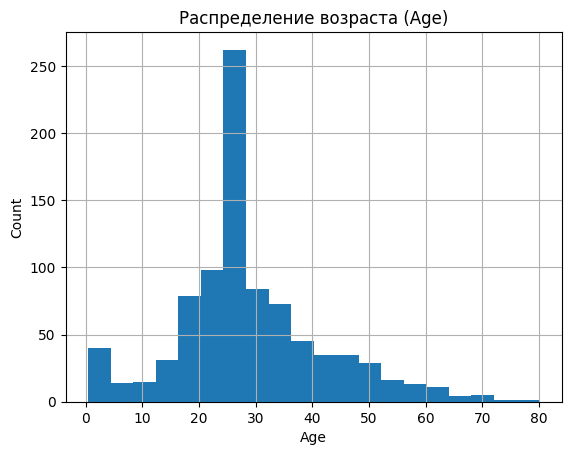

In [24]:
#Распределение возраста
if "Age" in df.columns:
    df["Age"].astype(float).hist(bins=20)
    plt.title("Распределение возраста (Age)")
    plt.xlabel("Age"); plt.ylabel("Count")
    plt.show()


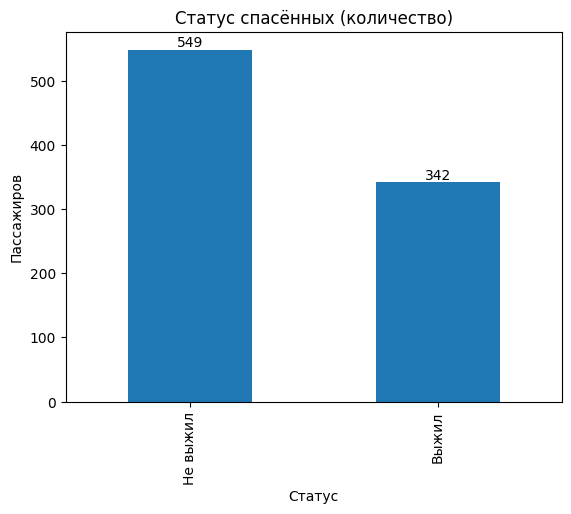

Доля выживших: 38% | не выживших: 62%


In [25]:
# количество выживших и не выживших
df["Survived"].value_counts(dropna=False)

# график с понятными подписями
ax = (df["Survived"]
      .value_counts()
      .sort_index()
      .rename(index={0: "Не выжил", 1: "Выжил"})
      .plot(kind="bar"))

plt.title("Статус спасённых (количество)")
plt.xlabel("Статус"); plt.ylabel("Пассажиров")

# подпишем числа над столбиками
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

# доли в процентах
share = df["Survived"].mean()
print(f"Доля выживших: {share:.0%} | не выживших: {1 - share:.0%}")


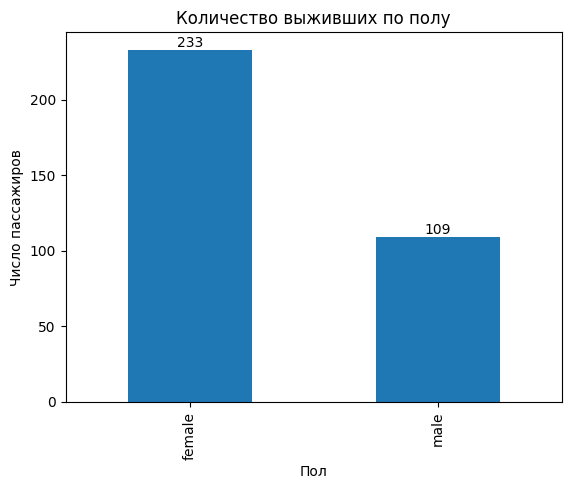

In [26]:
# гарантируем 0/1
df["Survived"] = df["Survived"].astype(int)

survived_by_sex = df.groupby("Sex")["Survived"].sum()  # сумма 1 = кол-во выживших
ax = survived_by_sex.plot(kind="bar")

plt.title("Количество выживших по полу")
plt.xlabel("Пол"); plt.ylabel("Число пассажиров")
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()


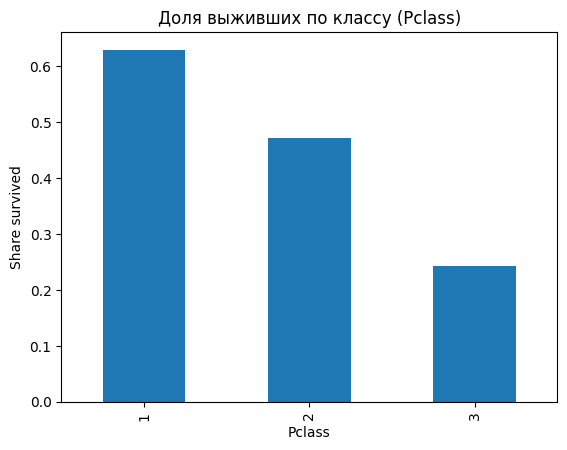

In [27]:
# Доля выживших по классу
if set(["Survived","Pclass"]).issubset(df.columns):
    (df.groupby("Pclass")["Survived"].mean()
      .sort_index()
      .plot(kind="bar"))
    plt.title("Доля выживших по классу (Pclass)")
    plt.xlabel("Pclass"); plt.ylabel("Share survived")
    plt.show()


In [28]:
# Сохраняем очищенный датасет
OUT_PATH = "titanic_cleaned.csv"
df.to_csv(OUT_PATH, index=False)
print("Сохранено в:", OUT_PATH, "| Размер:", df.shape)


Сохранено в: titanic_cleaned.csv | Размер: (891, 12)


## Количество выживших/не выживших по полу

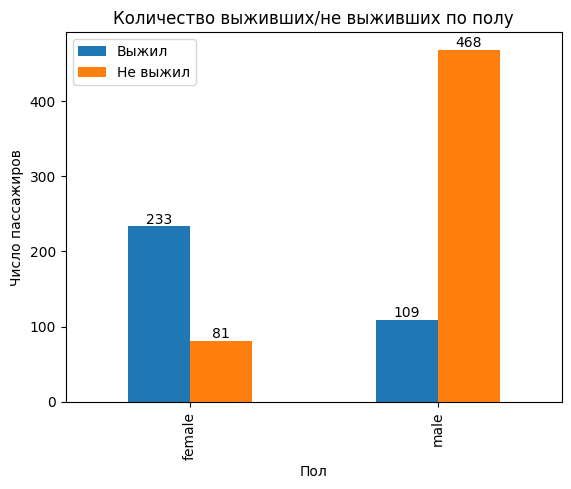

In [29]:
total_by_sex = df.groupby("Sex")["Survived"].size()
dead_by_sex = total_by_sex - survived_by_sex

counts = pd.DataFrame({
    "Выжил": survived_by_sex,
    "Не выжил": dead_by_sex
}).loc[sorted(df["Sex"].unique())]   # упорядочим по алфавиту

ax = counts.plot(kind="bar")
plt.title("Количество выживших/не выживших по полу")
plt.xlabel("Пол"); plt.ylabel("Число пассажиров")
for c in ax.containers:
    ax.bar_label(c, label_type="edge")
plt.show()


# Тепловая карта корреляций (числовые признаки)

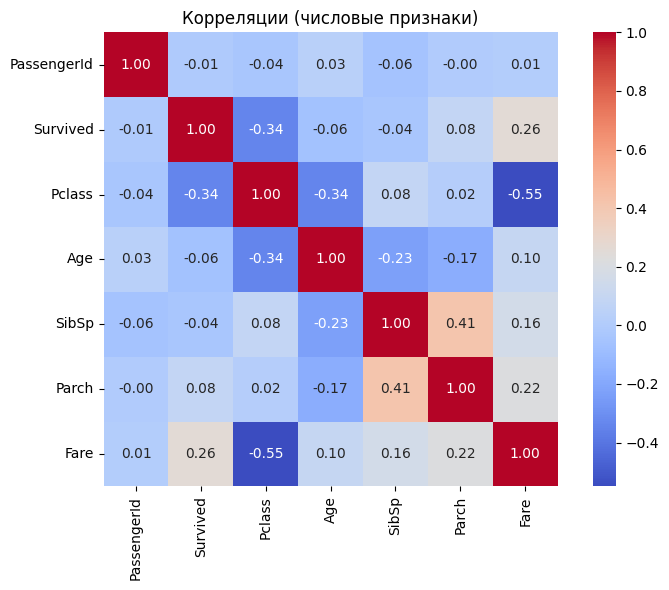

In [30]:
numeric = df.select_dtypes(include="number")
corr = numeric.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Корреляции (числовые признаки)")
plt.tight_layout()
plt.show()

### Минимальный пайплайн: кодируем категориальные, остальное пропускаем «как есть», учим неглубокое дерево и смотрим важности.

Accuracy: 0.793
              precision    recall  f1-score   support

           0       0.77      0.95      0.85       110
           1       0.86      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.82      0.75      0.76       179
weighted avg       0.81      0.79      0.78       179



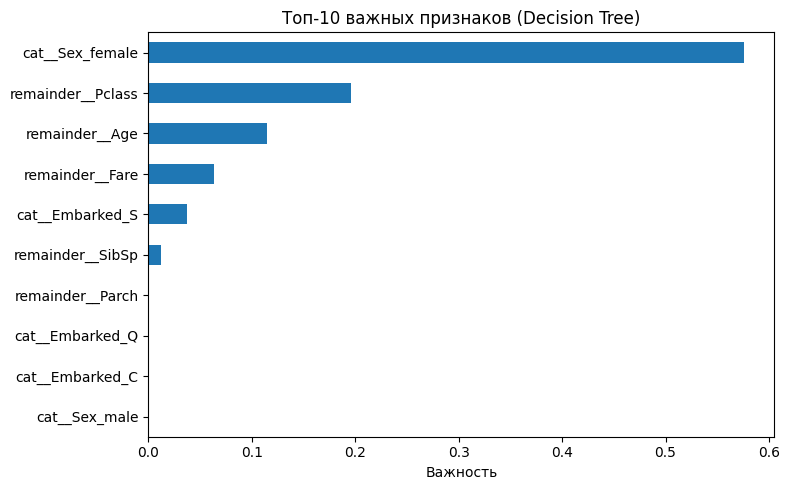

cat__Sex_female      0.576297
remainder__Pclass    0.195920
remainder__Age       0.114526
remainder__Fare      0.063141
cat__Embarked_S      0.037198
remainder__SibSp     0.012109
remainder__Parch     0.000809
cat__Sex_male        0.000000
cat__Embarked_C      0.000000
cat__Embarked_Q      0.000000
dtype: float64

In [31]:
# целевая переменная
y = df["Survived"].astype(int)

# базовый набор признаков (просто и понятно)
features = [
    "Sex", "Embarked",     # категориальные
    "Pclass", "Age", "Fare", "SibSp", "Parch"  # числовые
]
X = df[features].copy()

# раздельно перечислим типы столбцов
cat_cols = ["Sex", "Embarked"]
num_cols = ["Pclass", "Age", "Fare", "SibSp", "Parch"]

# препроцессор: one-hot для категорий, остальное как есть
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough"
)

# модель: неглубокое дерево, чтобы было читаемо
clf = DecisionTreeClassifier(max_depth=4, random_state=42)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", clf)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred))

# достанем имена признаков после OneHot
feature_names = pipe.named_steps["prep"].get_feature_names_out()
importances = pipe.named_steps["model"].feature_importances_

fi = (pd.Series(importances, index=feature_names)
        .sort_values(ascending=False)
        .head(10))

plt.figure(figsize=(8, 5))
fi.sort_values().plot(kind="barh")
plt.title("Топ-10 важных признаков (Decision Tree)")
plt.xlabel("Важность")
plt.tight_layout()
plt.show()

fi

Sex         0.576297
Pclass      0.195920
Age         0.114526
Fare        0.063141
Embarked    0.037198
SibSp       0.012109
Parch       0.000809
dtype: float64


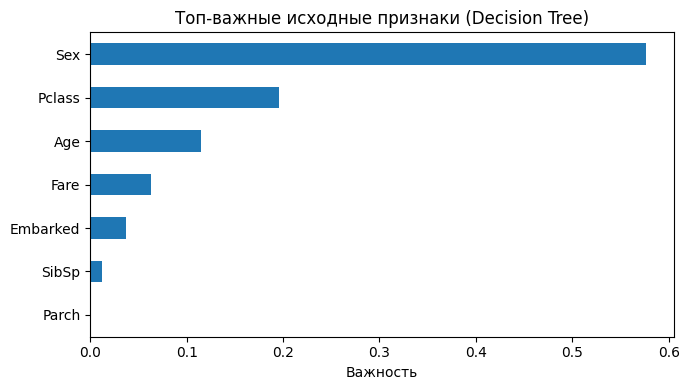

In [32]:
feature_names = pipe.named_steps["prep"].get_feature_names_out()
importances = pipe.named_steps["model"].feature_importances_

def orig_name(name: str) -> str:
    # 'cat__Sex_female' -> 'Sex'; 'remainder__Pclass' -> 'Pclass'; 'Fare' -> 'Fare'
    if "__" in name:
        right = name.split("__", 1)[1]     # 'Sex_female' или 'Pclass'
        return right.split("_", 1)[0]       # до первого '_' — исходное имя
    return name

agg = {}
for n, v in zip(feature_names, importances):
    agg[orig_name(n)] = agg.get(orig_name(n), 0.0) + v

fi_orig = pd.Series(agg).sort_values(ascending=False)
print(fi_orig.head(10))

# Красивый график
ax = fi_orig.head(10).sort_values().plot(kind="barh", figsize=(7,4))
ax.set_title("Топ-важные исходные признаки (Decision Tree)")
ax.set_xlabel("Важность")
plt.tight_layout()
plt.show()